In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load dataset
df = pd.read_csv("company_dataset.csv")
df.head(5)

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,0,TCS,3.8,(59.9k Reviews),Public,55 years old,"Mumbai,Maharashtra + 276 more",1 Lakh+ Employees (India)
1,1,Accenture,4.1,(38.3k Reviews),Public,34 years old,Dublin + 139 more,1 Lakh+ Employees (India)
2,2,Cognizant,3.9,(34.9k Reviews),Private,29 years old,Teaneck. New Jersey. + 109 more,1 Lakh+ Employees (India)
3,3,ICICI Bank,4.0,(28.5k Reviews),Public,29 years old,"Mumbai,Maharashtra + 1159 more",1 Lakh+ Employees (India)
4,4,Wipro,3.9,(28.4k Reviews),Public,78 years old,"Bangalore/Bengaluru,Karnataka + 235 more",1 Lakh+ Employees (India)


In [3]:
# Clean review count
df['review_count_clean'] = df['review_count'].str.replace(r'[^\d.]', '', regex=True)
df['review_count_clean'] = df['review_count_clean'].astype(float)


In [7]:
# Convert years column
df['years_clean'] = df['years'].str.extract(r'(\d+)').astype(float).fillna(0).astype(int)

In [ ]:
# Clean employees column
df['employees_clean'] = df['employees'].fillna("Unknown")

In [ ]:
# 1. HEADQUARTERS (Top 10)
# -----------------------------
top10_hq = df[['name', 'hq']].head(10)

print("\nTop 10 Company Headquarters:\n")
print(top10_hq.to_string(index=False))

In [ ]:
# 2. BAR CHART (Ratings Wise)
# -----------------------------
plt.figure(figsize=(12,6))
plt.bar(df['name'], df['ratings'], color='orange')
plt.xticks(rotation=90)
plt.title("Bar Chart: Company Ratings")
plt.xlabel("Company")
plt.ylabel("Rating")
plt.show()

In [ ]:
# 3. FUNNEL CHART (Matplotlib Style)
# -----------------------------
df_top10 = df.sort_values(by='review_count_clean', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(df_top10['name'], df_top10['review_count_clean'], color='skyblue')

# Invert y-axis to mimic funnel (largest on top)
plt.gca().invert_yaxis()

plt.title("Funnel Chart (Top 10 Companies by Reviews)")
plt.xlabel("Review Count")
plt.ylabel("Company")
plt.show()

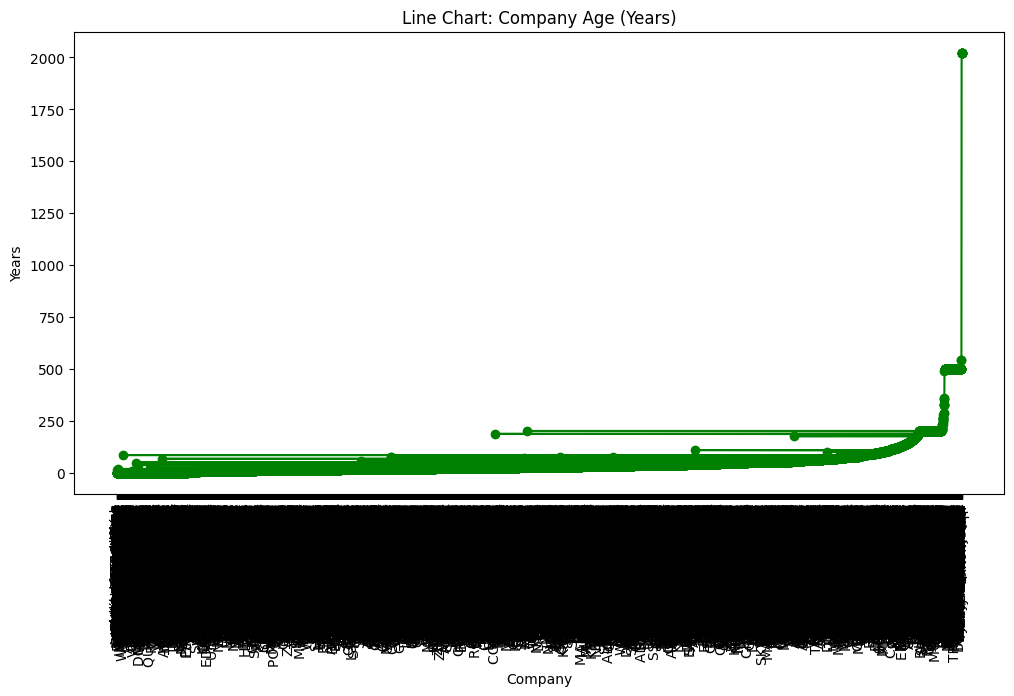

In [8]:
# 4. LINE CHART (Years Wise)
# -----------------------------
df_sorted_years = df.sort_values(by='years_clean')

plt.figure(figsize=(12,6))
plt.plot(df_sorted_years['name'], df_sorted_years['years_clean'], marker='o', linestyle='-', color='green')
plt.xticks(rotation=90)
plt.title("Line Chart: Company Age (Years)")
plt.xlabel("Company")
plt.ylabel("Years")
plt.show()

In [ ]:
# 5. PIE CHART (Employees Wise)
# -----------------------------
emp_counts = df['employees_clean'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(emp_counts, labels=emp_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Pie Chart: Company Distribution by Employee Size")
plt.show()